### xgb_ranker with synopses

This is a modification of the models made in the ```xgb_ranker.ipynb``` notebook with the addition of encoded synopses.

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
#%reset -f
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn
import sys

sys.path.append("../scripts")

In [19]:
books_tt = pd.read_csv('../data/books_engineered_train.csv')
books_tt.head()

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_urban,tag_urban fantasi,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi
0,4548,4548,The Hawkstone,Jay Williams,1971,Other,[''],False,False,10,...,0,0,0,0,0,0,0,0,0,0
1,4549,4549,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,Other,NaN,False,False,04,...,0,0,0,0,0,0,0,0,0,0
2,4550,4550,Swap Around the Ouija,John Dexter,1971,Other,NaN,False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0
3,4551,4551,The Sun Grows Cold,Howard Berk,1971,dell,['apocalyps'],False,False,01,...,0,0,0,0,0,0,0,0,0,0
4,4552,4552,The Seal-Singing,Rosemary Harris,1971,Other,['anim'],False,False,Unknown,...,0,0,0,0,0,0,0,0,0,0


In [20]:
books_tt.shape

(75108, 146)

In [21]:
books_tt.release_year.unique()

array([1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014])

In [22]:
# load in data with book_synopsis
books = pd.read_csv('../data/data_with_author_and_awards.csv',
dtype = {
    'isbn' : 'str', # do this explicitly to avoide getting a warning by the interpreter
    'author_birthyear' : 'Int64', # we have to explicitly do this to avoid pandas implicitly casting as float
    'title_id' : 'Int64'
},
)

books = books[(1971 <= books.release_year) & (books.release_year <= 2014)]

In [23]:
books.head()

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,...,hugo,locus,month_of_publication,Author_Age_at_Publication,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent
4548,2009247,The Hawkstone,Jay Williams,1971,1971-10-01,"Henry Z. Walck, Inc.",1914,"Buffalo, New York, USA",0809830965,"""A young New Englander is unaware of the stran...",...,False,False,10,57,0,0,False,False,USA,Central/North America
4549,1336959,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,1971-04-00,Paperback Library,1912,"St. John, New Brunswick, Canada",9781645550112,NaN,...,False,False,04,59,0,0,False,False,Canada,Central/North America
4550,3092565,Swap Around the Ouija,John Dexter,1971,1971-00-00,Greenleaf Classics,<NA>,NaN,NaN,A swapping group explores the occult; at least...,...,False,False,Unknown,Unknown,0,0,False,False,Unknown,Unknown
4551,679913,The Sun Grows Cold,Howard Berk,1971,1971-01-00,Dell,1925,"Brookline, Massachusetts, USA",0586039848,NaN,...,False,False,01,46,0,0,False,False,USA,Central/North America
4552,1997735,The Seal-Singing,Rosemary Harris,1971,1971-00-00,Faber and Faber,1923,"London, England, UK",0571096395,"""While spending the summer on a Scottish islan...",...,False,False,Unknown,48,0,0,False,False,UK,Europe


In [24]:
books.shape

(75108, 21)

In [25]:
books_tt = pd.merge(books_tt, books[['title', 'author', 'book_synopsis']], on = ['title', 'author'])

In [26]:
books_tt.shape

(75108, 147)

In [27]:
books_tt.book_synopsis = books_tt.book_synopsis.apply(lambda x : '' if pd.isnull(x) else x)

In [28]:
books_tt

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_urban fantasi,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi,book_synopsis
0,4548,4548,The Hawkstone,Jay Williams,1971,Other,[''],False,False,10,...,0,0,0,0,0,0,0,0,0,"""A young New Englander is unaware of the stran..."
1,4549,4549,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,Other,NaN,False,False,04,...,0,0,0,0,0,0,0,0,0,
2,4550,4550,Swap Around the Ouija,John Dexter,1971,Other,NaN,False,False,Unknown,...,0,0,0,0,0,0,0,0,0,A swapping group explores the occult; at least...
3,4551,4551,The Sun Grows Cold,Howard Berk,1971,dell,['apocalyps'],False,False,01,...,0,0,0,0,0,0,0,0,0,
4,4552,4552,The Seal-Singing,Rosemary Harris,1971,Other,['anim'],False,False,Unknown,...,0,0,0,0,0,0,0,0,0,"""While spending the summer on a Scottish islan..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75103,79651,79651,Path of the Dead,Timothy Baker,2014,Other,"['thriller', 'fantasi']",False,False,05,...,0,0,0,0,0,0,0,0,0,Nestled on the foot of Tibet's sacred Seche La...
75104,79652,79652,Ure Infectus,Caleb Wachter,2014,Other,[''],False,False,09,...,0,0,0,0,0,0,0,0,0,
75105,79653,79653,Exile,Chris Ward,2014,Other,NaN,False,False,01,...,0,0,0,0,0,0,0,0,0,
75106,79654,79654,Superheroes Anonymous,Lexie Dunne,2014,Other,['superhero'],False,False,11,...,0,0,0,0,0,0,0,0,0,


In [29]:
sys.path.append('../')
import scripts.feature_engineering.tagging_system.automate_tagging as at

In [30]:
transformer = at.load_transformer()

books_tt['encoded_synopsis'] = books_tt.book_synopsis.apply(transformer.encode)

/tmp/ipykernel_6939/2050645497.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  books_tt['encoded_synopsis'] = books_tt.book_synopsis.apply(transformer.encode)


In [31]:
books_tt

,Unnamed: 0.1,Unnamed: 0,title,author,release_year,first_publisher,tags,hugo,locus,month_of_publication,...,tag_vampir,tag_video gam,tag_war,tag_weak character develop,tag_weird,tag_werewolf,tag_ya,tag_zombi,book_synopsis,encoded_synopsis
0,4548,4548,The Hawkstone,Jay Williams,1971,Other,[''],False,False,10,...,0,0,0,0,0,0,0,0,"""A young New Englander is unaware of the stran...","[-0.036100663, 0.10305314, 0.032459974, 0.0384..."
1,4549,4549,"Barnabas, Quentin and Dr. Jekyll's Son",Marilyn Ross,1971,Other,NaN,False,False,04,...,0,0,0,0,0,0,0,0,,"[-0.1188384, 0.048298758, -0.0025481568, -0.01..."
2,4550,4550,Swap Around the Ouija,John Dexter,1971,Other,NaN,False,False,Unknown,...,0,0,0,0,0,0,0,0,A swapping group explores the occult; at least...,"[-0.03329423, 0.002571326, 0.022237577, 0.0351..."
3,4551,4551,The Sun Grows Cold,Howard Berk,1971,dell,['apocalyps'],False,False,01,...,0,0,0,0,0,0,0,0,,"[-0.1188384, 0.048298758, -0.0025481568, -0.01..."
4,4552,4552,The Seal-Singing,Rosemary Harris,1971,Other,['anim'],False,False,Unknown,...,0,0,0,0,0,0,0,0,"""While spending the summer on a Scottish islan...","[-0.07222478, 0.048827797, -0.00031475644, 0.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75103,79651,79651,Path of the Dead,Timothy Baker,2014,Other,"['thriller', 'fantasi']",False,False,05,...,0,0,0,0,0,0,0,0,Nestled on the foot of Tibet's sacred Seche La...,"[-0.104558006, 0.030457908, -0.012535447, 0.02..."
75104,79652,79652,Ure Infectus,Caleb Wachter,2014,Other,[''],False,False,09,...,0,0,0,0,0,0,0,0,,"[-0.1188384, 0.048298758, -0.0025481568, -0.01..."
75105,79653,79653,Exile,Chris Ward,2014,Other,NaN,False,False,01,...,0,0,0,0,0,0,0,0,,"[-0.1188384, 0.048298758, -0.0025481568, -0.01..."
75106,79654,79654,Superheroes Anonymous,Lexie Dunne,2014,Other,['superhero'],False,False,11,...,0,0,0,0,0,0,0,0,,"[-0.1188384, 0.048298758, -0.0025481568, -0.01..."


We shall use **walk-forward nested time series cross-validation**.

In [32]:
from walkforward_cv import walk_forward

windows = walk_forward(books_tt)


In [33]:
print(len(windows))

39


In [34]:
from xgb_ranker_with_synopses_model import SynopsisXGBRanker
model = SynopsisXGBRanker()


In [35]:
num_finalists = 60 # the top 60 ranked will be labeled as finalists.

from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import average_precision_score, ndcg_score
from sklearn.metrics import recall_score


cv_data = []

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()
    year = book_val['release_year'].mode()


    model.fit(
                book_train, # because the pipeline already accounts for all the features, we don't need to input it here.
                book_train['target']
            )

    ypred = model.predict(book_val)
    
    book_val['predicted_score'] = ypred

    book_val['rank_within_year'] = book_val.groupby('release_year')['predicted_score'].rank(
            method='first', 
            ascending=False
        )
    
    book_val['predicted'] = (book_val['rank_within_year'] <= num_finalists).astype(int)

    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)
    precision = average_precision_score(book_val['target'], book_val['predicted'].values)

    cv_data.append({'fold': num, "val_year": year.values, 'f1_score': f1score, 'recall': recall, 'precision': precision})
    print(num)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38


In [36]:
cv_result = pd.DataFrame(cv_data)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.31594026701043293
STD of f1 score across folds:  0.13211149794092003


So here, we see that the model performs significantly worse than the original model without dropping books with no descriptions.

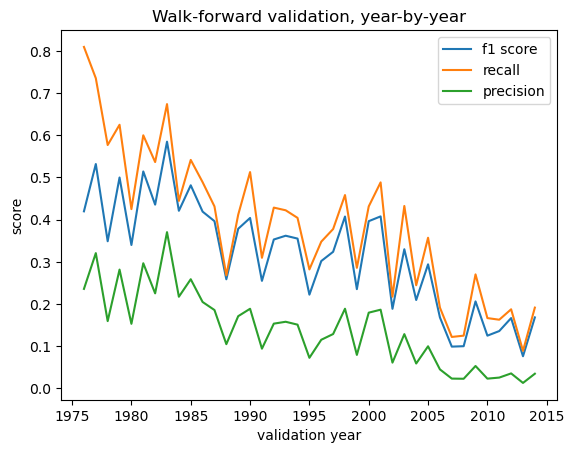

In [37]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()
plt.show()

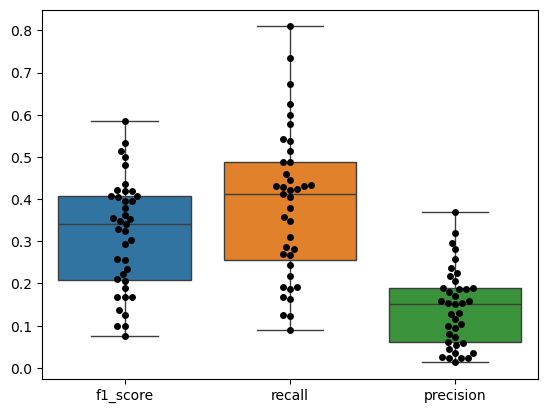

In [38]:
import seaborn as sns


ax = sns.boxplot(data=cv_result[['f1_score', 'recall', 'precision']])

sns.swarmplot(data=cv_result[['f1_score', 'recall', 'precision']], ax=ax, color='black')

plt.show()

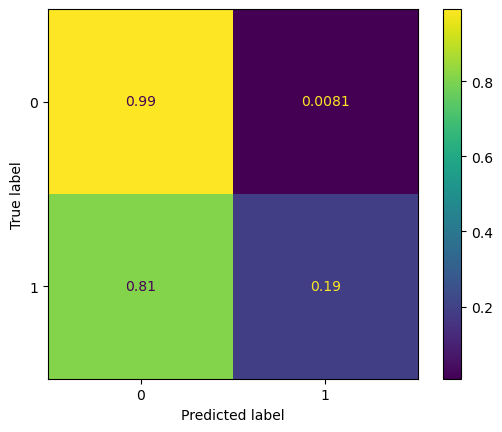

In [39]:
conf = confusion_matrix(book_val['target'], book_val['predicted'], normalize='true')#.ravel().tolist()

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=conf).plot()

plt.show()


Let us look at the most important features.

In [40]:
feature_names = model.model.named_steps['preprocess'].get_feature_names_out()

importances = model.model.named_steps['xgb_rank'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(20))

                                              Feature  Importance
82                                 synopsis__knn_pred    0.645127
0          numerical_scaling__Total_Awards_Previously    0.103747
3      numerical_scaling__years_since_last_nomination    0.079532
81        nominee_,similarity__past_winner_similarity    0.017409
80                 tag_similarity__cohort_similiarity    0.015004
4   numerical_scaling__publisher_historical_nomina...    0.012727
45                      onehot__first_publisher_orbit    0.012144
63                        onehot__first_publisher_tor    0.010415
19              onehot__first_publisher_bantamspectra    0.010225
2                 numerical_scaling__author_num_books    0.008857
48                onehot__first_publisher_pocketbooks    0.007538
17            onehot__first_publisher_ballantinebooks    0.007437
1        numerical_scaling__Author_Age_at_Publication    0.007404
30                  onehot__first_publisher_doubleday    0.007218
32        

Since here the ```synopsis__knn_pred``` feature is much more important than all other features, we should still be pretty predictive even on debut novels and authors.

In [41]:
identified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted'] == 1)]
unidentified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted'] == 0)]

In [42]:
book_val[book_val['target'] == 1][['title', 'author', 'Total_Awards_Previously']]

,title,author,Total_Awards_Previously
68850,Shipstar,"Gregory Benford, Larry Niven",1.0
68865,Skin Game,Jim Butcher,0.0
68870,Steles of the Sky,Elizabeth Bear,6.0
68877,Afterparty,Daryl Gregory,2.0
68891,Artemis Awakening,Jane Lindskold,1.0
68899,My Real Children,Jo Walton,6.0
69100,War Dogs,Greg Bear,22.0
69104,Lagoon,Nnedi Okorafor,1.0
69409,Full Fathom Five,Max Gladstone,0.0
69411,All Those Vanished Engines,Paul Park,5.0


In [43]:
identified_noms['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
2.0    3
0.0    2
1.0    1
6.0    1
5.0    1
3.0    1
Name: count, dtype: int64

In [44]:
unidentified_noms['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
0.0     12
1.0     11
2.0      3
6.0      2
22.0     2
9.0      2
13.0     2
4.0      1
3.0      1
14.0     1
18.0     1
Name: count, dtype: int64

In [45]:
identified_noms['NomineeBefore'].value_counts()

NomineeBefore
True     7
False    2
Name: count, dtype: int64

In [46]:
unidentified_noms['NomineeBefore'].value_counts()

NomineeBefore
True     26
False    12
Name: count, dtype: int64

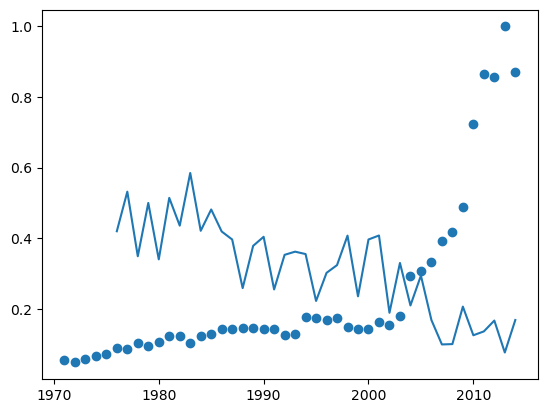

In [47]:
newbie_count = books_tt.groupby('release_year')['new_author'].sum()

years = newbie_count.index.values
values = newbie_count.values

plt.scatter(years, values/np.max(values))
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')

plt.show()

Now we explore what happens if we drop all books without descriptions.

In [48]:
books_tt = pd.read_csv('../data/books_engineered_train.csv')
books = pd.read_csv('../data/data_with_author_and_awards.csv',
dtype = {
    'isbn' : 'str', # do this explicitly to avoide getting a warning by the interpreter
    'author_birthyear' : 'Int64', # we have to explicitly do this to avoid pandas implicitly casting as float
    'title_id' : 'Int64'
},
)

books = books[(1971 <= books.release_year) & (books.release_year <= 2014)]


books_tt = pd.merge(books_tt, books[['title', 'author', 'book_synopsis']], on = ['title', 'author'])

In [49]:
books_tt = books_tt.dropna(subset=['book_synopsis']) # this massively shrinks our dataset

In [50]:
books_tt['encoded_synopsis'] = books_tt.book_synopsis.apply(transformer.encode)

/tmp/ipykernel_6939/1984131673.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  books_tt['encoded_synopsis'] = books_tt.book_synopsis.apply(transformer.encode)


In [51]:
from walkforward_cv import walk_forward
from xgb_ranker_with_synopses_model import SynopsisXGBRanker


windows = walk_forward(books_tt)
model = SynopsisXGBRanker()


In [52]:
num_finalists = 60 # the top 60 ranked will be labeled as finalists.

from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import average_precision_score, ndcg_score
from sklearn.metrics import recall_score


cv_data = []

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()
    year = book_val['release_year'].mode()


    model.fit(
                book_train, # because the pipeline already accounts for all the features, we don't need to input it here.
                book_train['target']
            )

    ypred = model.predict(book_val)
    
    book_val['predicted_score'] = ypred

    book_val['rank_within_year'] = book_val.groupby('release_year')['predicted_score'].rank(
            method='first', 
            ascending=False
        )
    
    book_val['predicted'] = (book_val['rank_within_year'] <= num_finalists).astype(int)

    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)
    precision = average_precision_score(book_val['target'], book_val['predicted'].values)

    cv_data.append({'fold': num, "val_year": year.values, 'f1_score': f1score, 'recall': recall, 'precision': precision})
    print(num)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38


In [53]:
cv_result = pd.DataFrame(cv_data)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.3204869358491854
STD of f1 score across folds:  0.1346967717210694


Unfortunately, performance here is still very bad.

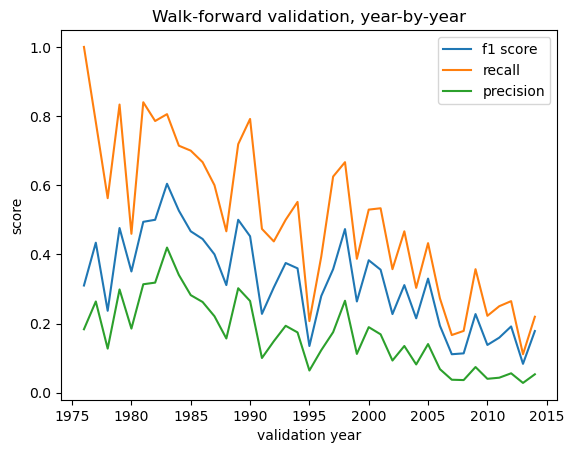

In [54]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()
plt.show()

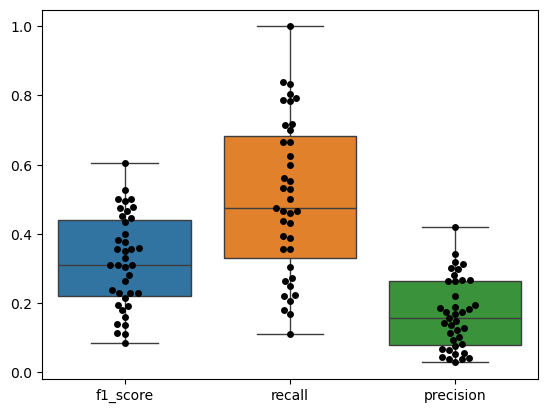

In [55]:
import seaborn as sns


ax = sns.boxplot(data=cv_result[['f1_score', 'recall', 'precision']])

sns.swarmplot(data=cv_result[['f1_score', 'recall', 'precision']], ax=ax, color='black')

plt.show()

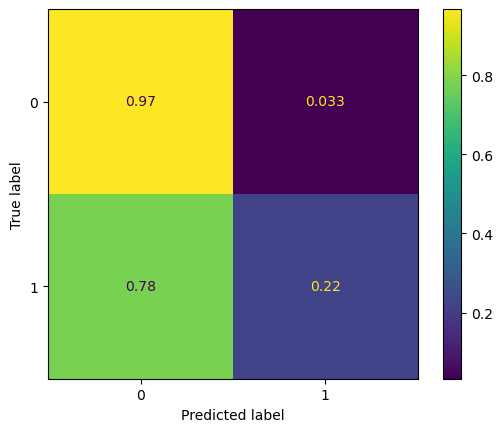

In [56]:
conf = confusion_matrix(book_val['target'], book_val['predicted'], normalize='true')#.ravel().tolist()

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=conf).plot()

plt.show()


In [57]:
identified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted'] == 1)]
unidentified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted'] == 0)]

In [58]:
identified_noms['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
2.0    3
0.0    2
1.0    1
6.0    1
5.0    1
3.0    1
Name: count, dtype: int64

In [59]:
unidentified_noms['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
1.0     9
0.0     8
2.0     3
6.0     2
22.0    2
9.0     2
13.0    2
4.0     1
3.0     1
14.0    1
18.0    1
Name: count, dtype: int64

In [60]:
identified_noms['NomineeBefore'].value_counts()

NomineeBefore
True     7
False    2
Name: count, dtype: int64

In [61]:
unidentified_noms['NomineeBefore'].value_counts()

NomineeBefore
True     24
False     8
Name: count, dtype: int64

This does not appear to be any different than the previous model where we did not drop anything. Here the ratio of new vs already nominated authors seem pretty similar, so it does not appear to be a great factor in our model.

If we dropped every N/A entry and inputted into our model, we do actually find a small gain in performance against the baseline model.

In [62]:
books_tt = pd.read_csv('../data/books_engineered_train.csv')
books = pd.read_csv('../data/data_with_author_and_awards.csv',
dtype = {
    'isbn' : 'str', # do this explicitly to avoide getting a warning by the interpreter
    'author_birthyear' : 'Int64', # we have to explicitly do this to avoid pandas implicitly casting as float
    'title_id' : 'Int64'
},
)

books = books[(1971 <= books.release_year) & (books.release_year <= 2014)]

books_tt = pd.merge(books_tt, books[['title', 'author', 'book_synopsis']], on = ['title', 'author'])

In [63]:
books_tt.shape

(75108, 147)

In [64]:
books_tt = at.encode_books(books_tt, transformer) # This function automatically applies the dropna() method

/home/tiger/Documents/erdos/summer26-nomination-worthy-books/CLEAN-REPO/models/../scripts/feature_engineering/tagging_system/automate_tagging.py:604: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  books['encoded_synopsis'] = books.book_synopsis.apply(transformer.encode)


In [65]:
books_tt.shape # however, our sample size is now much smaller
               # we can justify this by nothing that 2845 is still larger than say 10 * 148
               # and is around 20 * 148, so we can still do a reasonable model.

(2845, 148)

In [66]:
from walkforward_cv import walk_forward
from xgb_ranker_with_synopses_model import SynopsisXGBRanker


windows = walk_forward(books_tt)
model = SynopsisXGBRanker()


In [96]:
num_finalists = 60 # the top 60 ranked will be labeled as finalists.

cv_data = []

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]

    book_train = book_train.copy()
    book_val = book_val.copy()
    year = book_val['release_year'].mode()


    model.fit(
                book_train, # because the pipeline already accounts for all the features, we don't need to input it here.
                book_train['target']
            )

    ypred = model.predict(book_val)
    
    book_val['predicted_score'] = ypred

    book_val['rank_within_year'] = book_val.groupby('release_year')['predicted_score'].rank(
            method='first', 
            ascending=False
        )
    
    book_val['predicted'] = (book_val['rank_within_year'] <= num_finalists).astype(int)

    f1score = f1_score(book_val['target'], book_val['predicted'].values)
    recall = recall_score(book_val['target'], book_val['predicted'].values)
    precision = average_precision_score(book_val['target'], book_val['predicted'].values)

    cv_data.append({'fold': num, "val_year": year.values, 'f1_score': f1score, 'recall': recall, 'precision': precision})
    print(num)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38


In [68]:
cv_result = pd.DataFrame(cv_data)
print("Mean f1 score across folds: ", cv_result['f1_score'].mean())
print("STD of f1 score across folds: ", cv_result['f1_score'].std())

Mean f1 score across folds:  0.5368885972855165
STD of f1 score across folds:  0.0755209396363605


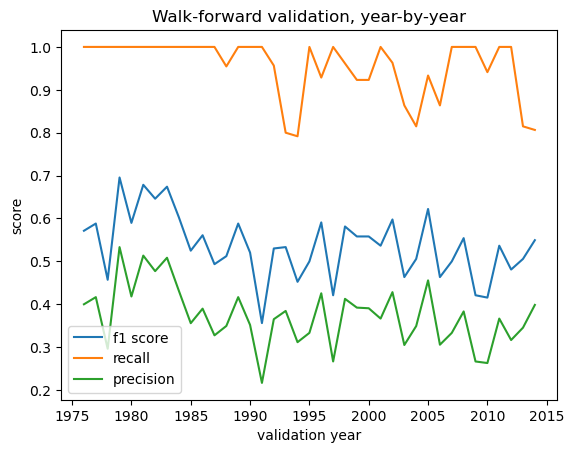

In [69]:
plt.plot([year[0] for year in cv_result['val_year']], cv_result['f1_score'], label='f1 score')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['recall'], label='recall')
plt.plot([year[0] for year in cv_result['val_year']], cv_result['precision'], label='precision')
plt.xlabel("validation year")
plt.ylabel("score")
plt.title('Walk-forward validation, year-by-year')
plt.legend()
plt.show()

Somehow by dropping all entries with *any* unknown value, it seems that our model improves dramatically. 

/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 15.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


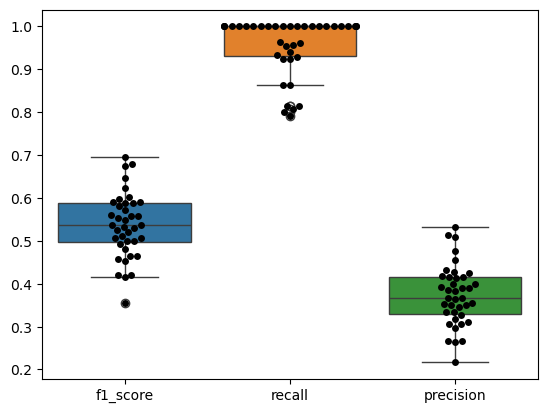

In [95]:
ax = sns.boxplot(data=cv_result[['f1_score', 'recall', 'precision']])

sns.swarmplot(data=cv_result[['f1_score', 'recall', 'precision']], ax=ax, color='black')

plt.show()

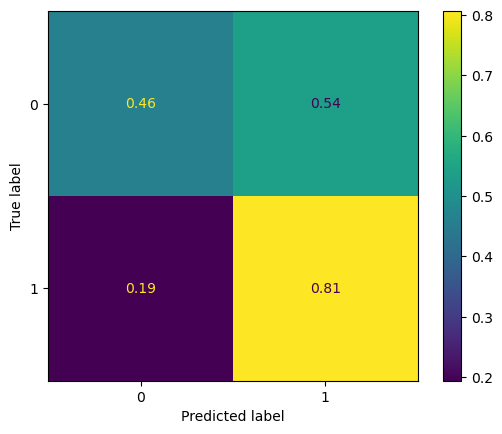

In [99]:
conf = confusion_matrix(book_val['target'], book_val['predicted'], normalize='true')#.ravel().tolist()

ConfusionMatrixDisplay(confusion_matrix=conf).plot()

plt.show()

In [72]:
identified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted'] == 1)]
unidentified_noms = book_val[(book_val['target'] == 1) & (book_val['predicted'] == 0)]


In [73]:
identified_noms['Total_Awards_Previously'].value_counts()


Total_Awards_Previously
1.0     7
2.0     4
6.0     3
22.0    2
9.0     2
3.0     2
13.0    2
5.0     1
14.0    1
18.0    1
Name: count, dtype: int64

In [74]:
unidentified_noms['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
1.0    3
2.0    2
4.0    1
Name: count, dtype: int64

In [75]:
identified_noms['NomineeBefore'].value_counts()

NomineeBefore
True    25
Name: count, dtype: int64

In [76]:
unidentified_noms['NomineeBefore'].value_counts()

NomineeBefore
True    6
Name: count, dtype: int64

Lets see how the codes on just a single train/test split.

Our data set spans the years 1971---2014, which is 43 years. 
We can split 34 years as train data.

Train: 1971---2005
Test: 2005---2014

In [77]:
book_train = books_tt[books_tt.release_year <= 2005]
book_test = books_tt[books_tt.release_year > 2005]

In [78]:
num_finalists = 60 # the top 60 ranked will be labeled as finalists.



book_train = book_train.copy()
book_test = book_test.copy()


model.fit(
            book_train, # because the pipeline already accounts for all the features, we don't need to input it here.
            book_train['target']
        )

ypred = model.predict(book_test)

book_test['predicted_score'] = ypred

book_test['rank_within_year'] = book_test.groupby('release_year')['predicted_score'].rank(
        method='first', 
        ascending=False
    )

book_test['predicted'] = (book_test['rank_within_year'] <= num_finalists).astype(int)

f1score = f1_score(book_test['target'], book_test['predicted'].values)
recall = recall_score(book_test['target'], book_test['predicted'].values)
precision = average_precision_score(book_test['target'], book_test['predicted'].values)



In [79]:
f1score

0.48032564450474896

In [80]:
recall

0.8984771573604061

In [81]:
precision

0.31913138789560985

This seems not too different from what we had during cross-validation. So this gives some confidence that our model is valid *when* we have all the features as non-null entries available to us.

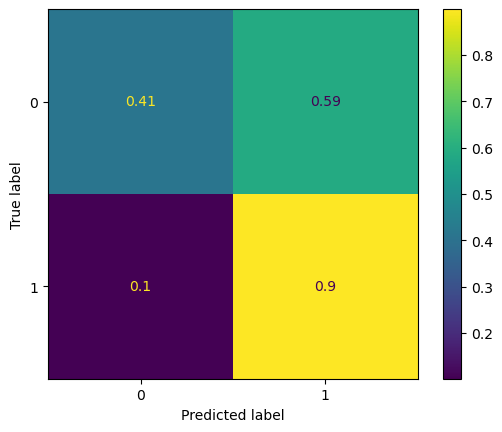

In [82]:
cm = confusion_matrix(book_test['target'], book_test['predicted'], normalize = 'true')
ConfusionMatrixDisplay(cm).plot()
plt.show()

The confusion matrix here is telling us that we have a lot of false positives. This could be an indication of the model identifying books with nomination quality writing. After all, there are only so many books that can get nominated every year.